# Parkinson's Disease Detection — Exploratory Data Analysis

We explore a dataset of voice measurements from 31 people (23 with Parkinson's, 8 healthy controls) to find acoustic features that distinguish PD voices from healthy ones.

**Dataset**: 195 voice recordings, 22 numeric features, target = `status` (1 = Parkinson's, 0 = healthy).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/parkinsons.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (195, 24)


,name,Fo_Hz,Fhi_Hz,Flo_Hz,Jitter_pct,Jitter_Abs,RAP,PPQ,Jitter_DDP,Shimmer,...,Shimmer_DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          195 non-null    object 
 1   Fo_Hz         195 non-null    float64
 2   Fhi_Hz        195 non-null    float64
 3   Flo_Hz        195 non-null    float64
 4   Jitter_pct    195 non-null    float64
 5   Jitter_Abs    195 non-null    float64
 6   RAP           195 non-null    float64
 7   PPQ           195 non-null    float64
 8   Jitter_DDP    195 non-null    float64
 9   Shimmer       195 non-null    float64
 10  Shimmer_dB    195 non-null    float64
 11  Shimmer_APQ3  195 non-null    float64
 12  Shimmer_APQ5  195 non-null    float64
 13  APQ           195 non-null    float64
 14  Shimmer_DDA   195 non-null    float64
 15  NHR           195 non-null    float64
 16  HNR           195 non-null    float64
 17  status        195 non-null    int64  
 18  RPDE          195 non-null    

In [4]:
df.describe().round(3)

,Fo_Hz,Fhi_Hz,Flo_Hz,Jitter_pct,Jitter_Abs,RAP,PPQ,Jitter_DDP,Shimmer,Shimmer_dB,...,Shimmer_DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000,195.000,195.000,195.000,195.0,195.000,195.000,195.000,195.000,195.000,...,195.000,195.000,195.000,195.000,195.000,195.000,195.000,195.000,195.000,195.000
mean,154.229,197.105,116.325,0.006,0.0,0.003,0.003,0.010,0.030,0.282,...,0.047,0.025,21.886,0.754,0.499,0.718,-5.684,0.227,2.382,0.207
std,41.390,91.492,43.521,0.005,0.0,0.003,0.003,0.009,0.019,0.195,...,0.030,0.040,4.426,0.432,0.104,0.055,1.090,0.083,0.383,0.090
min,88.333,102.145,65.476,0.002,0.0,0.001,0.001,0.002,0.010,0.085,...,0.014,0.001,8.441,0.000,0.257,0.574,-7.965,0.006,1.423,0.045
25%,117.572,134.862,84.291,0.003,0.0,0.002,0.002,0.005,0.017,0.148,...,0.025,0.006,19.198,1.000,0.421,0.675,-6.450,0.174,2.099,0.137
50%,148.790,175.829,104.315,0.005,0.0,0.002,0.003,0.007,0.023,0.221,...,0.038,0.012,22.085,1.000,0.496,0.722,-5.721,0.219,2.362,0.194
75%,182.769,224.206,140.019,0.007,0.0,0.004,0.004,0.012,0.038,0.350,...,0.061,0.026,25.075,1.000,0.588,0.762,-5.046,0.279,2.636,0.253
max,260.105,592.030,239.170,0.033,0.0,0.021,0.020,0.064,0.119,1.302,...,0.169,0.315,33.047,1.000,0.685,0.825,-2.434,0.450,3.671,0.527


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Unique recordings: {df['name'].nunique()}")
# Subject IDs hidden in `name` column (phon_R01_S01_1 etc.) — extract subject
df["subject"] = df["name"].str.extract(r"_S(\d+)_")
print(f"Unique subjects: {df['subject'].nunique()}")

Duplicate rows : 0
Unique recordings: 195
Unique subjects: 32


## 4. Missing / Invalid Values

In [6]:
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


## 5. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/1323038612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="status", data=df, palette="Set2", ax=axes[0], order=[0, 1])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/1323038612.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Healthy (0)", "Parkinson's (1)"])


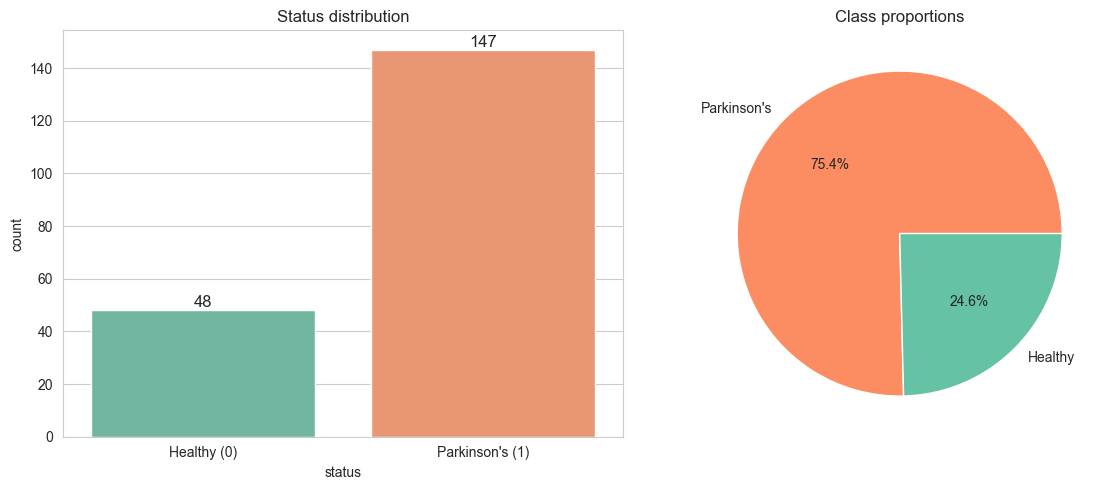

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="status", data=df, palette="Set2", ax=axes[0], order=[0, 1])
axes[0].set_xticklabels(["Healthy (0)", "Parkinson's (1)"])
axes[0].set_title("Status distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

df["status"].value_counts().plot.pie(
    labels=["Parkinson's","Healthy"], autopct="%1.1f%%",
    colors=["#fc8d62","#66c2a5"], ax=axes[1])
axes[1].set_ylabel(""); axes[1].set_title("Class proportions")
plt.tight_layout(); plt.show()

## 6. Univariate — Feature Distributions

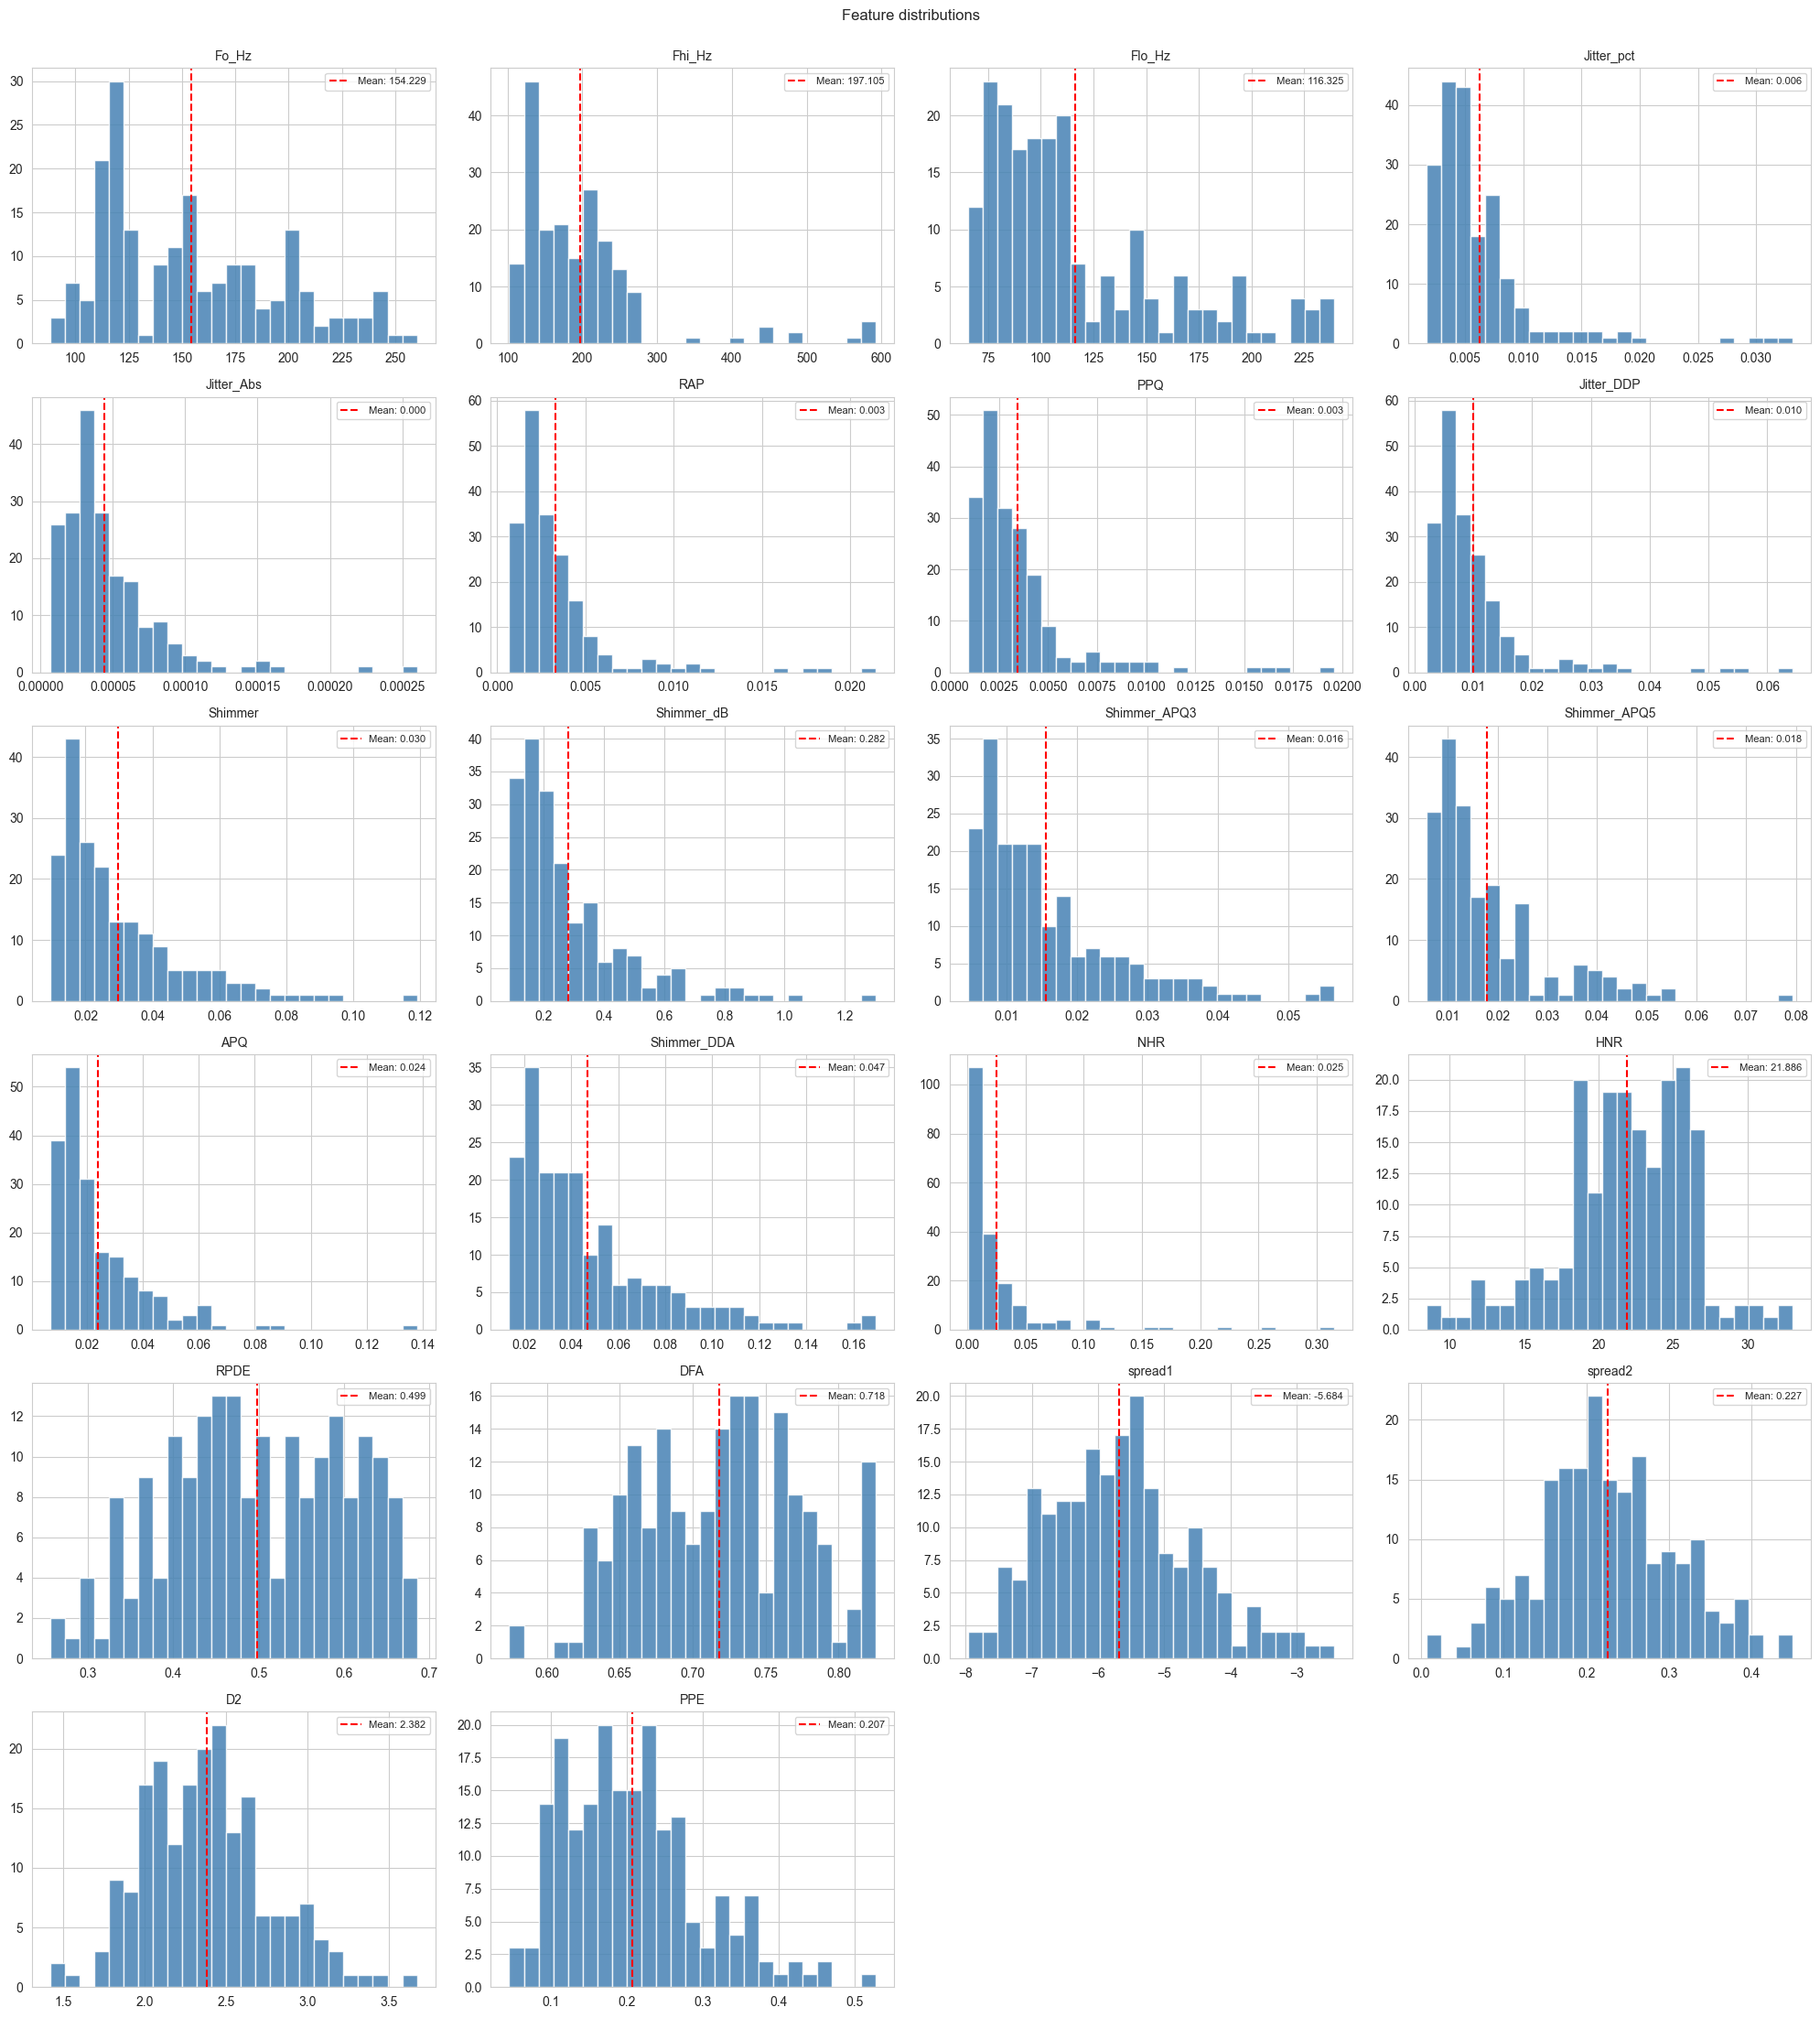

In [8]:
features = [c for c in df.columns if c not in {"name","status","subject"}]
fig, axes = plt.subplots(6, 4, figsize=(20, 22))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--",
                    label=f"Mean: {df[col].mean():.3f}")
    axes[i].set_title(col, fontsize=10); axes[i].legend(fontsize=8)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Feature distributions", y=1.0); plt.tight_layout(); plt.show()

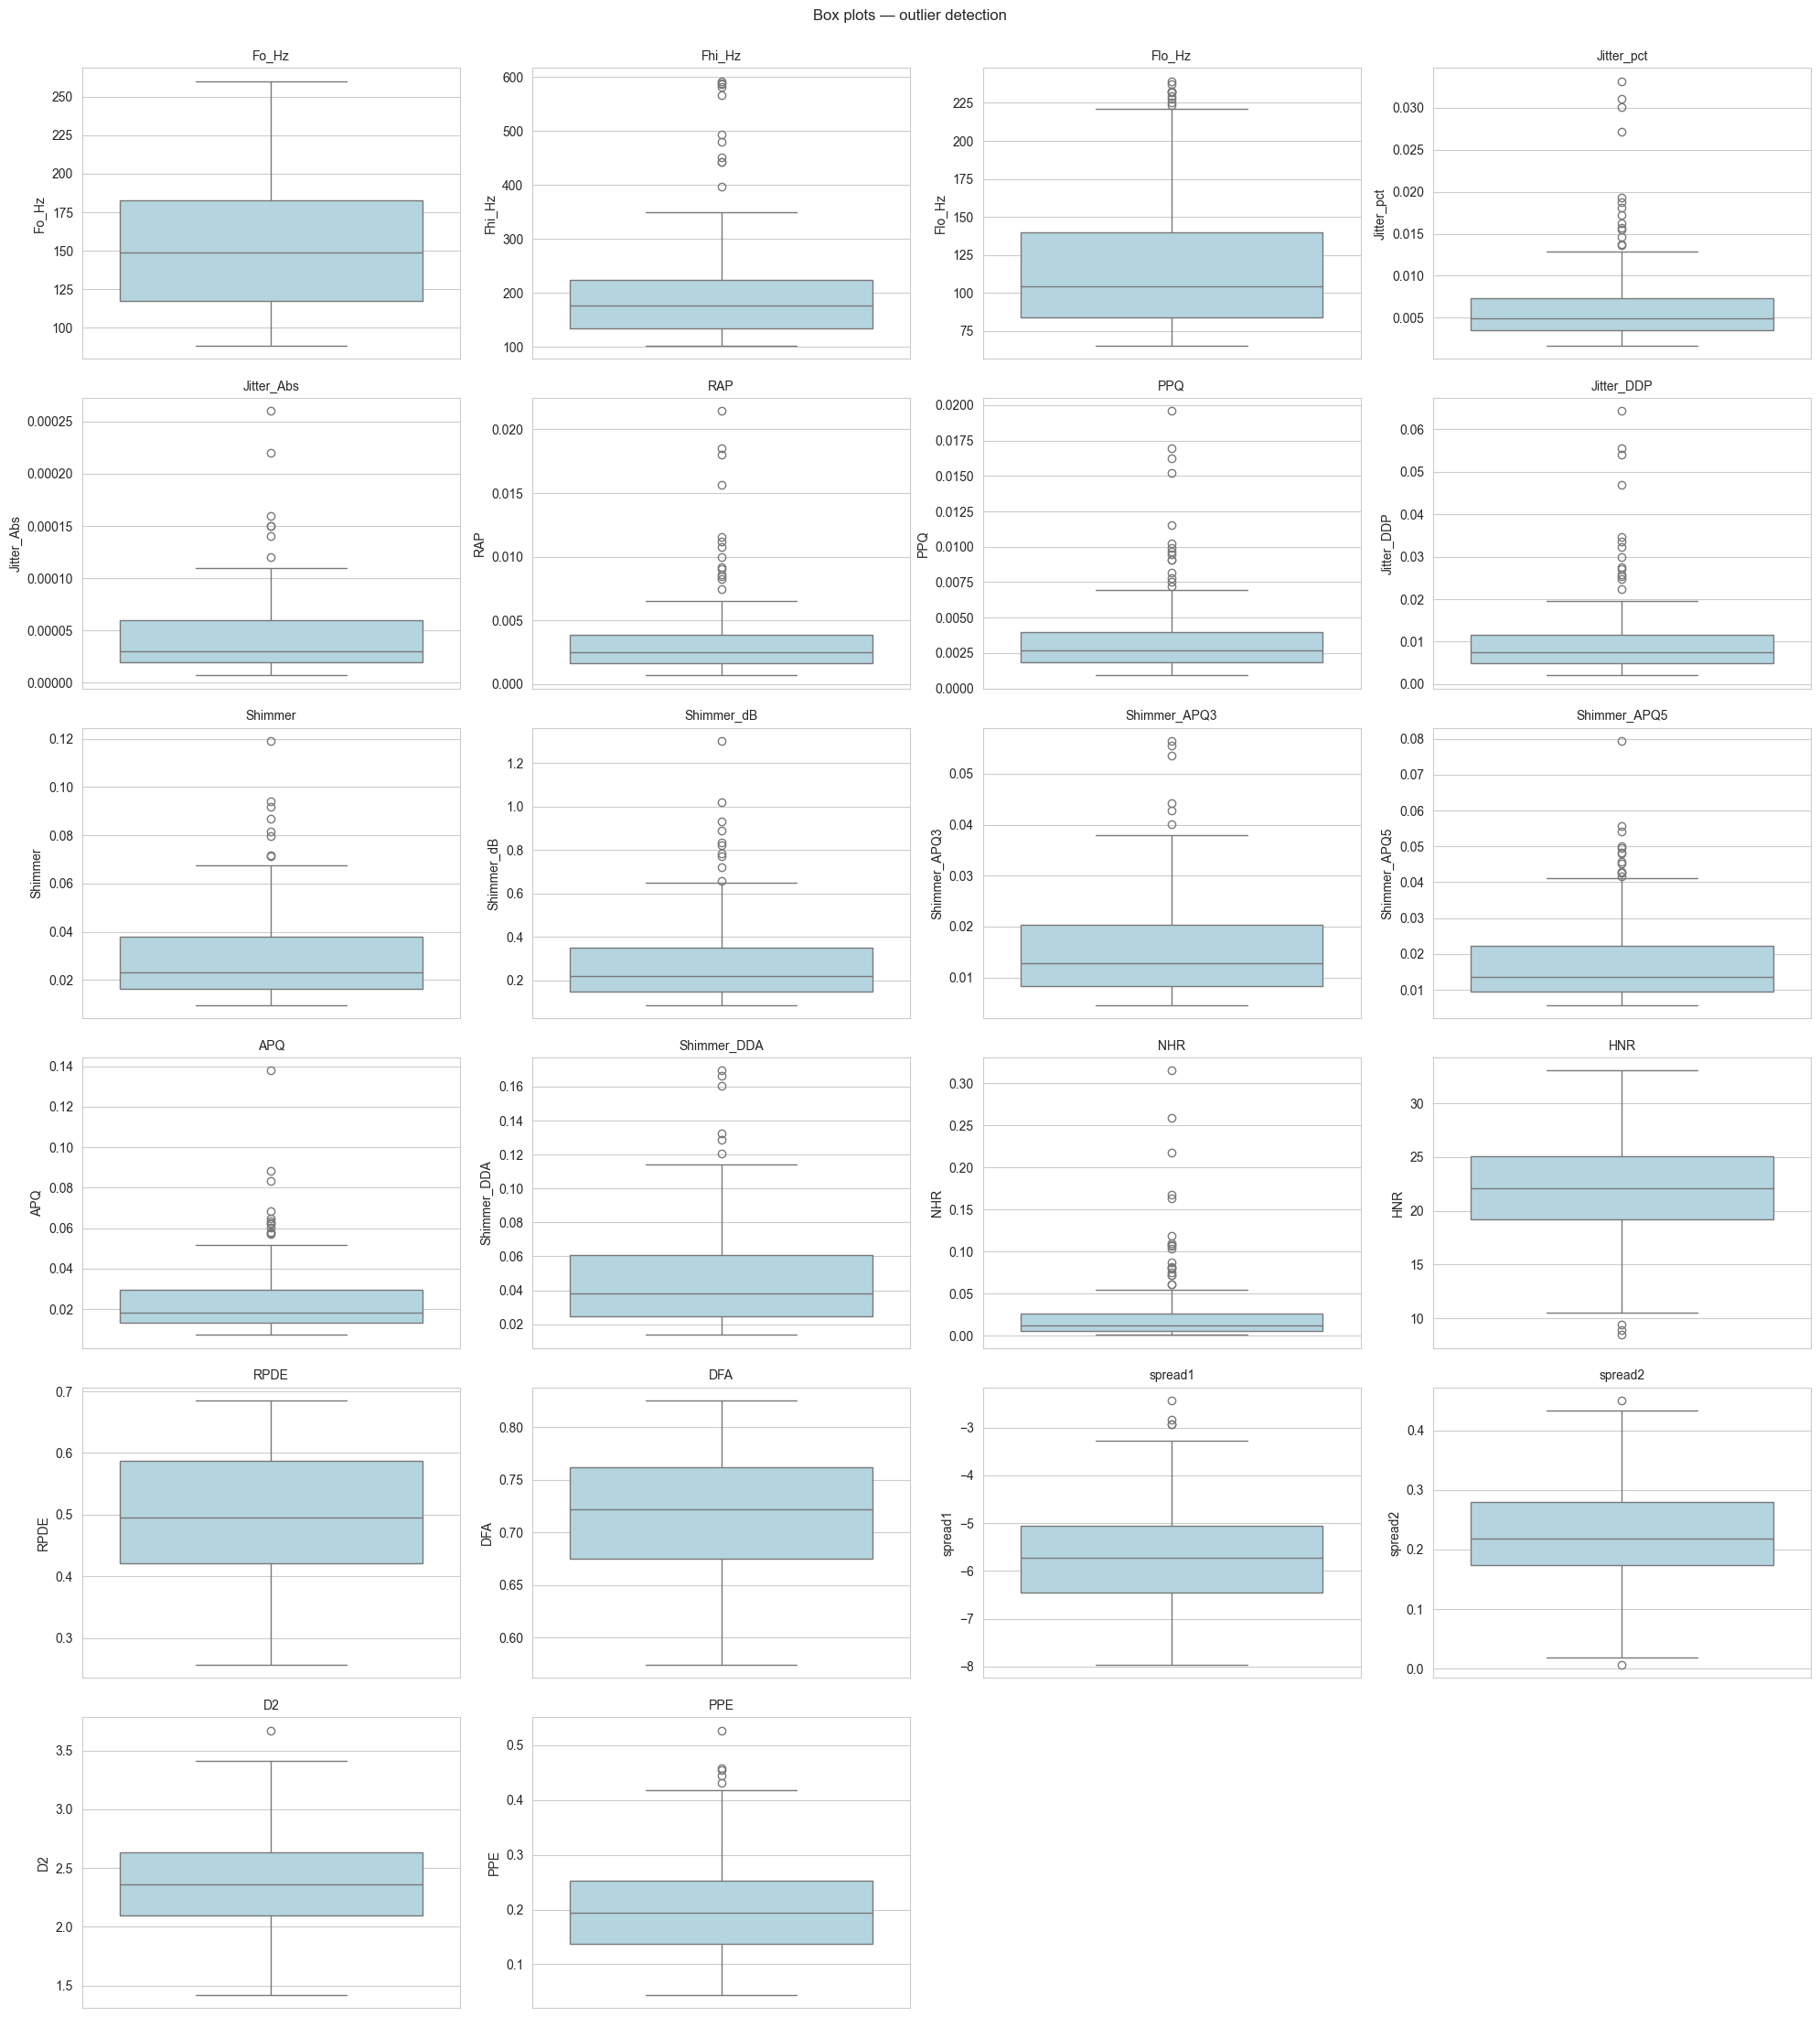

In [9]:
fig, axes = plt.subplots(6, 4, figsize=(20, 22))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col, fontsize=10)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Box plots — outlier detection", y=1.0)
plt.tight_layout(); plt.show()

## 7. Bivariate — Features vs Status

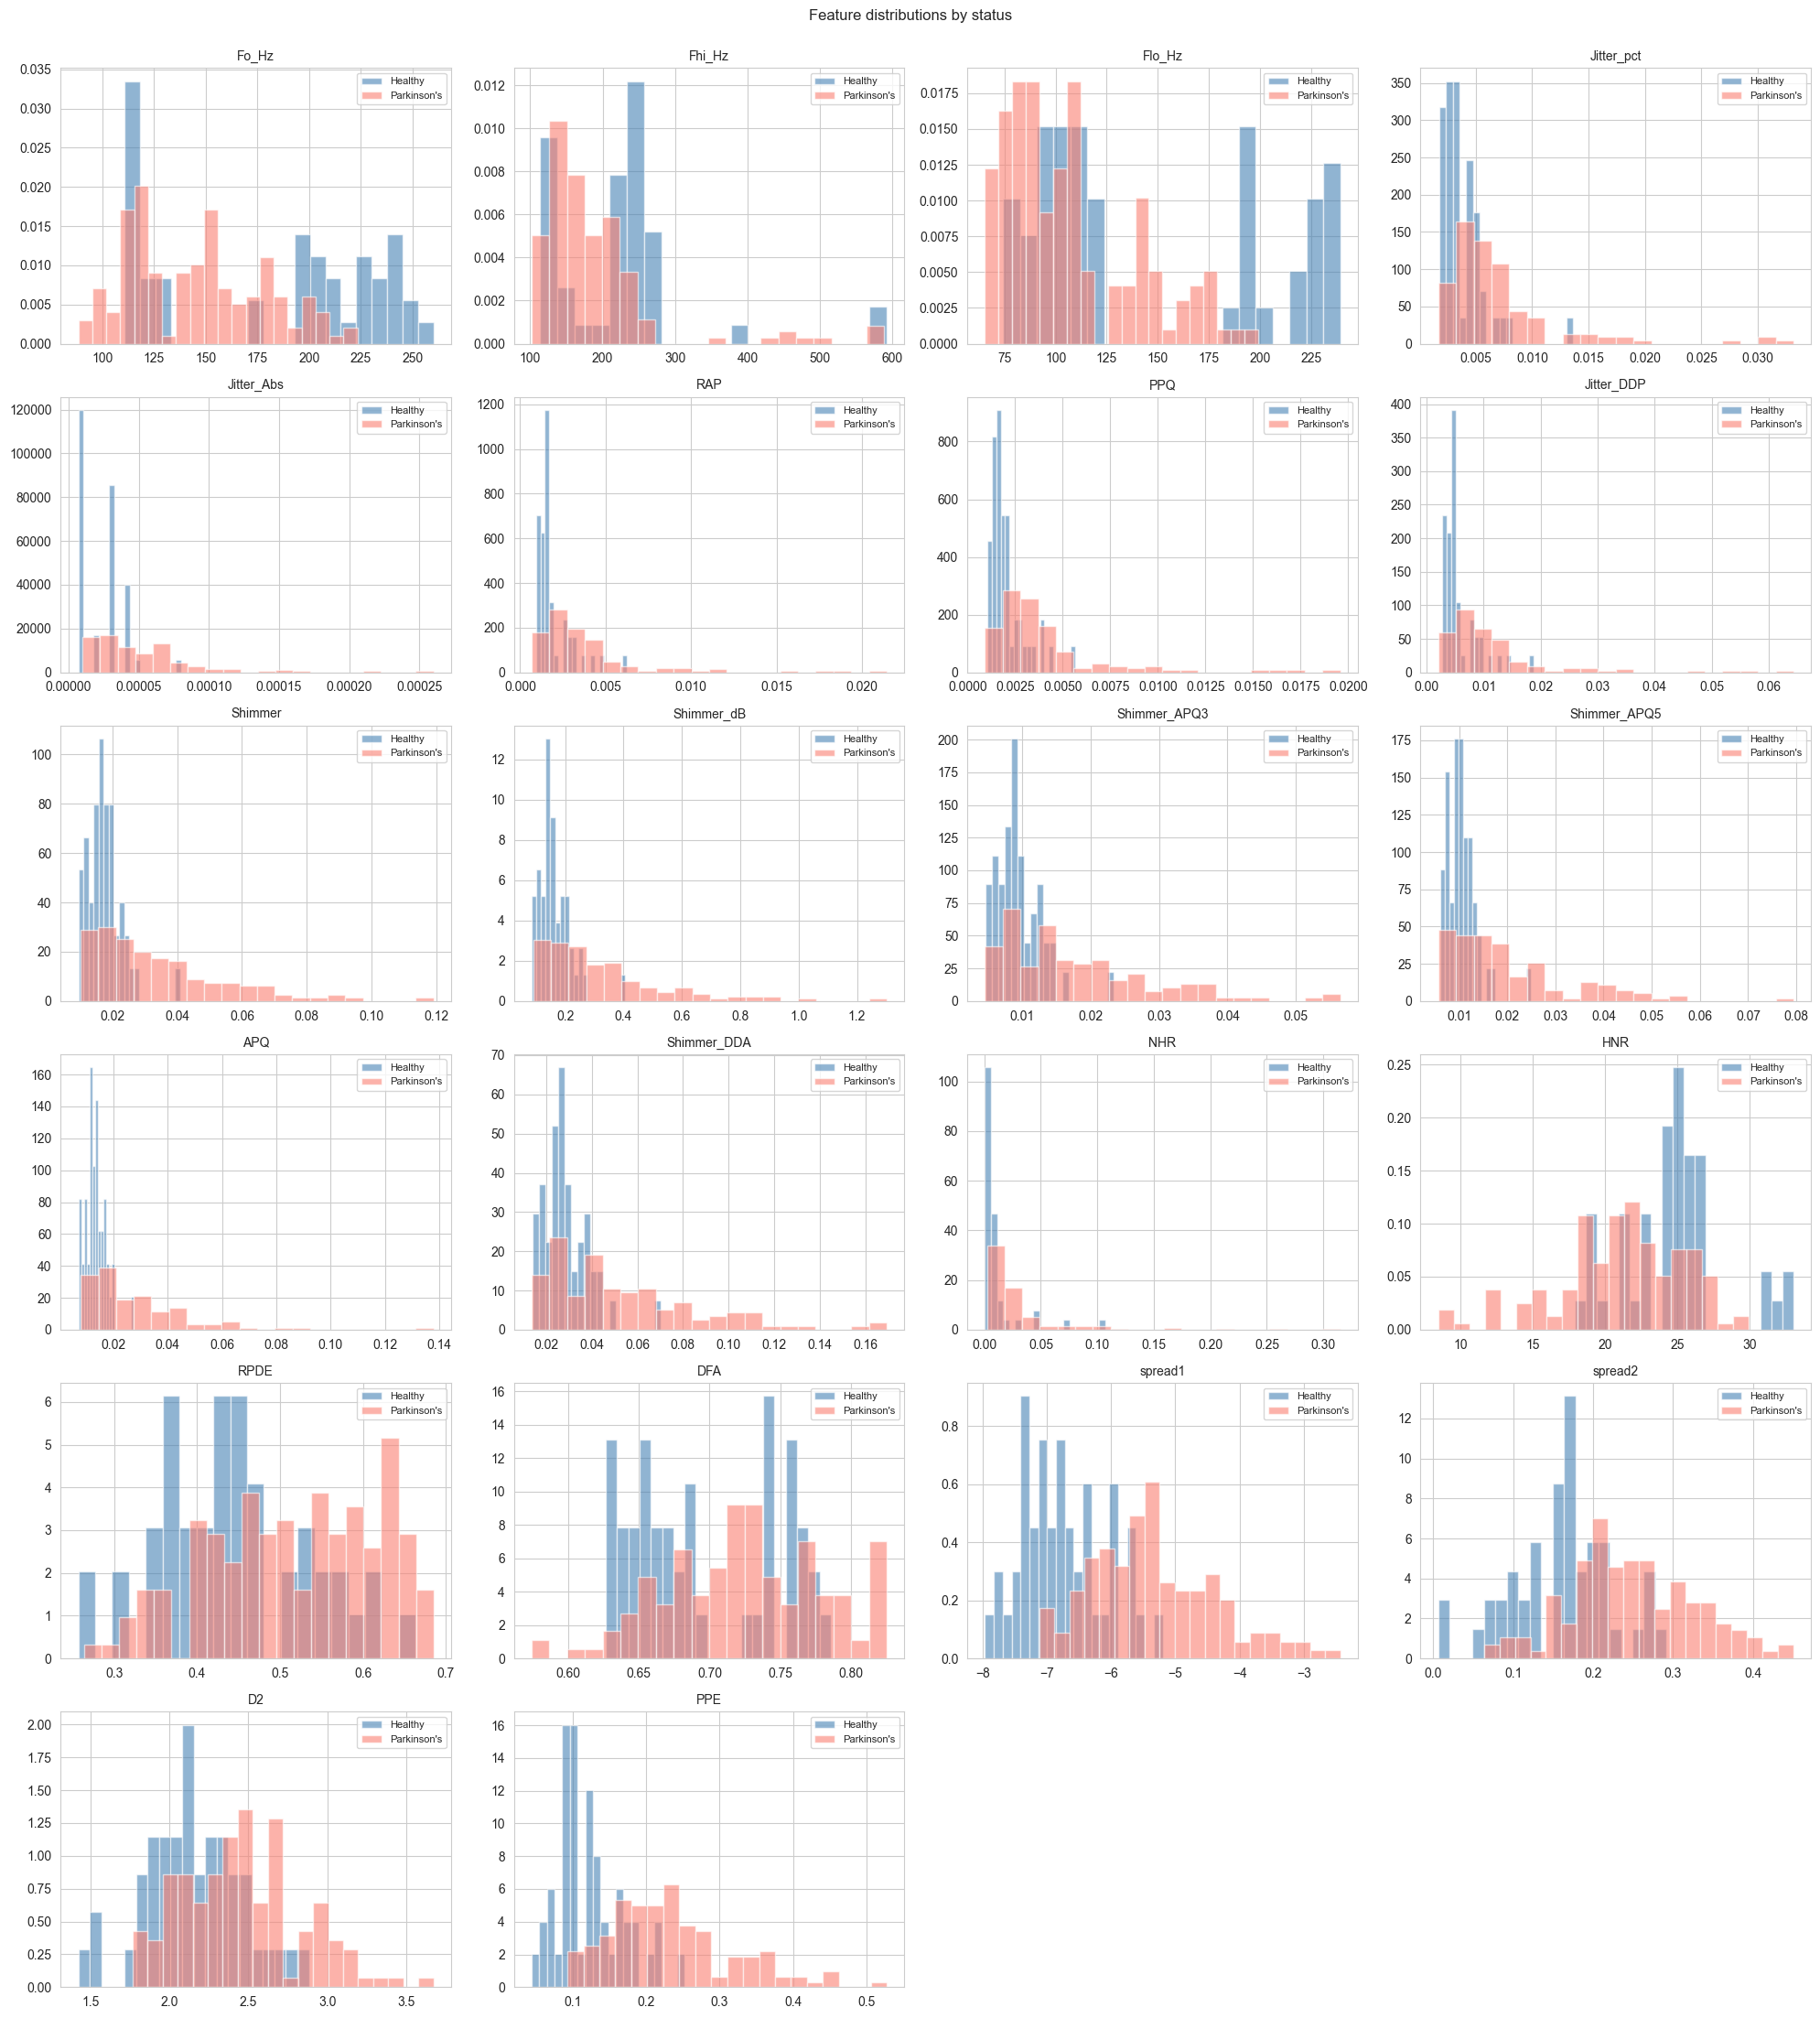

In [10]:
fig, axes = plt.subplots(6, 4, figsize=(20, 22))
axes = axes.flatten()
for i, col in enumerate(features):
    for s, color, label in [(0, "steelblue", "Healthy"), (1, "salmon", "Parkinson's")]:
        sub = df[df["status"] == s][col]
        axes[i].hist(sub, bins=20, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10); axes[i].legend(fontsize=8)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Feature distributions by status", y=1.0)
plt.tight_layout(); plt.show()

In [11]:
comparison = df.groupby("status")[features].mean().T
comparison.columns = ["Healthy", "Parkinson's"]
comparison["Difference"] = comparison["Parkinson's"] - comparison["Healthy"]
comparison["% Higher (PD)"] = (comparison["Difference"] / comparison["Healthy"] * 100).round(1)
comparison.round(4)

,Healthy,Parkinson's,Difference,% Higher (PD)
Fo_Hz,181.9378,145.1808,-36.7570,-20.2
Fhi_Hz,223.6368,188.4415,-35.1953,-15.7
Flo_Hz,145.2073,106.8936,-38.3137,-26.4
Jitter_pct,0.0039,0.0070,0.0031,80.8
Jitter_Abs,0.0000,0.0001,0.0000,116.8
RAP,0.0019,0.0038,0.0018,95.2
PPQ,0.0021,0.0039,0.0018,89.7
Jitter_DDP,0.0058,0.0113,0.0055,95.2
Shimmer,0.0176,0.0337,0.0160,91.1
Shimmer_dB,0.1630,0.3212,0.1582,97.1


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/3534384618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="status", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/3534384618.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Healthy", "Parkinson's"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/3534384618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="status", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_6

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/3534384618.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Healthy", "Parkinson's"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/3534384618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="status", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_61304/3534384618.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Healthy", "Parkinson's"])


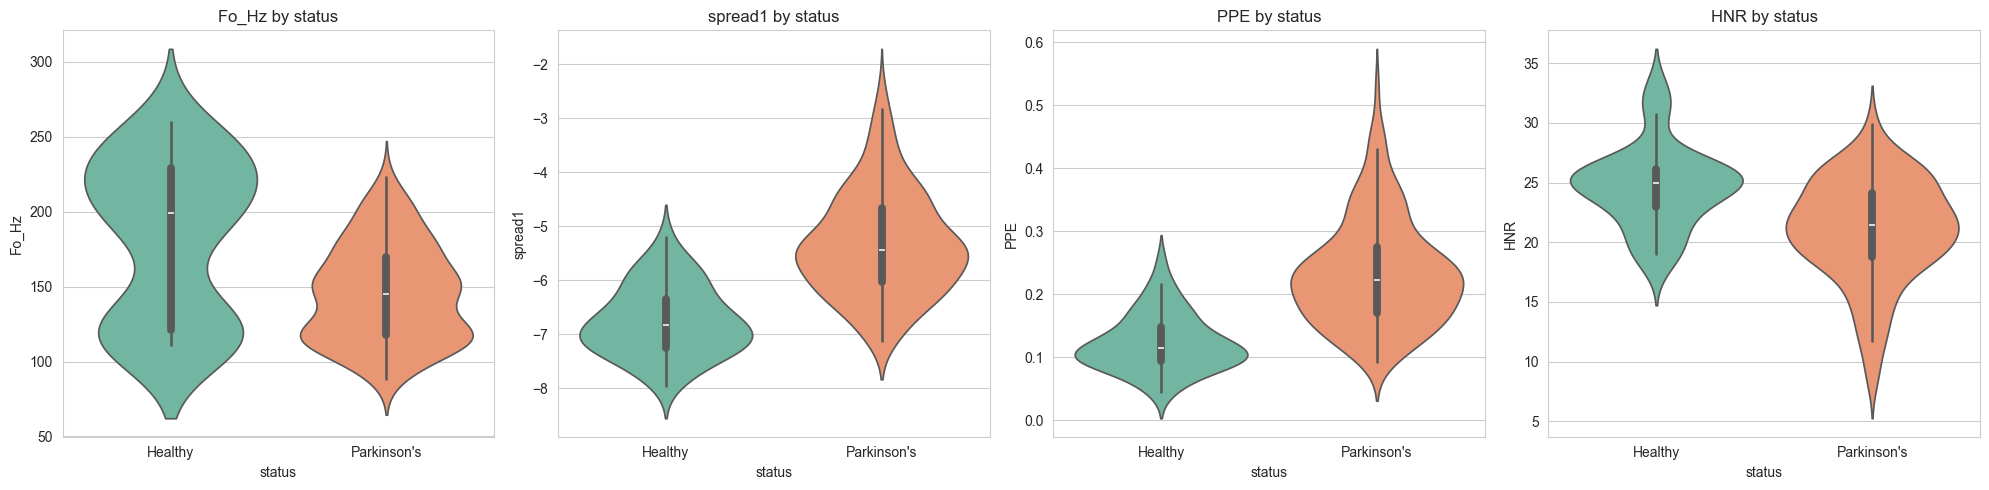

In [12]:
key = ["Fo_Hz", "spread1", "PPE", "HNR"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(key):
    sns.violinplot(x="status", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_xticklabels(["Healthy", "Parkinson's"])
    axes[i].set_title(f"{col} by status")
plt.tight_layout(); plt.show()

## 8. Correlation Analysis

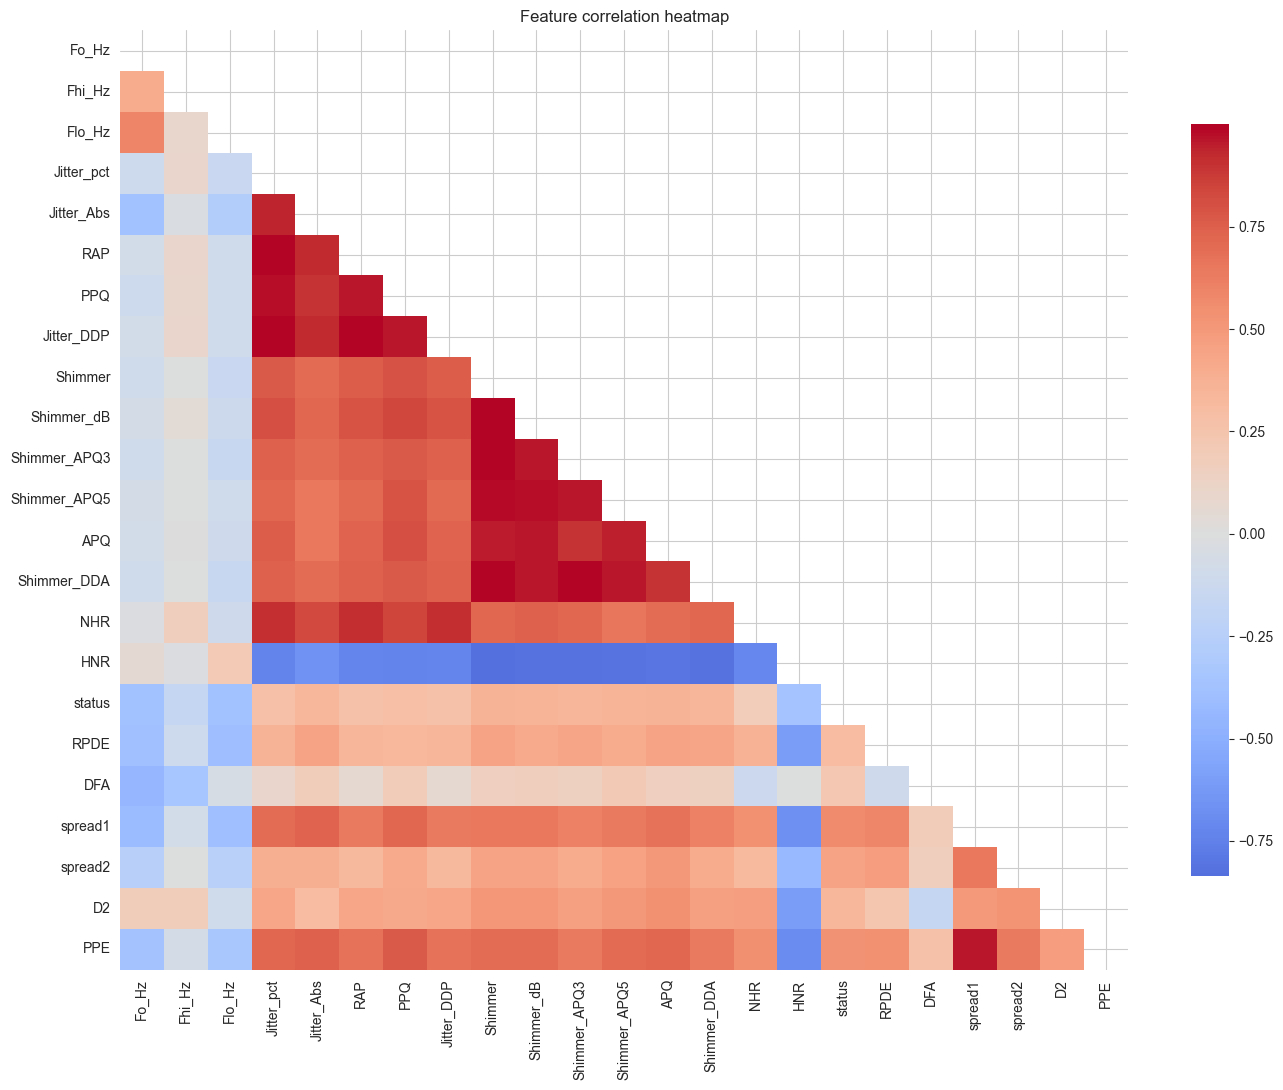

In [13]:
plt.figure(figsize=(14, 11))
df_num = df.drop(columns=["name","subject"], errors="ignore")
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=False,
            cbar_kws={"shrink": 0.8})
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

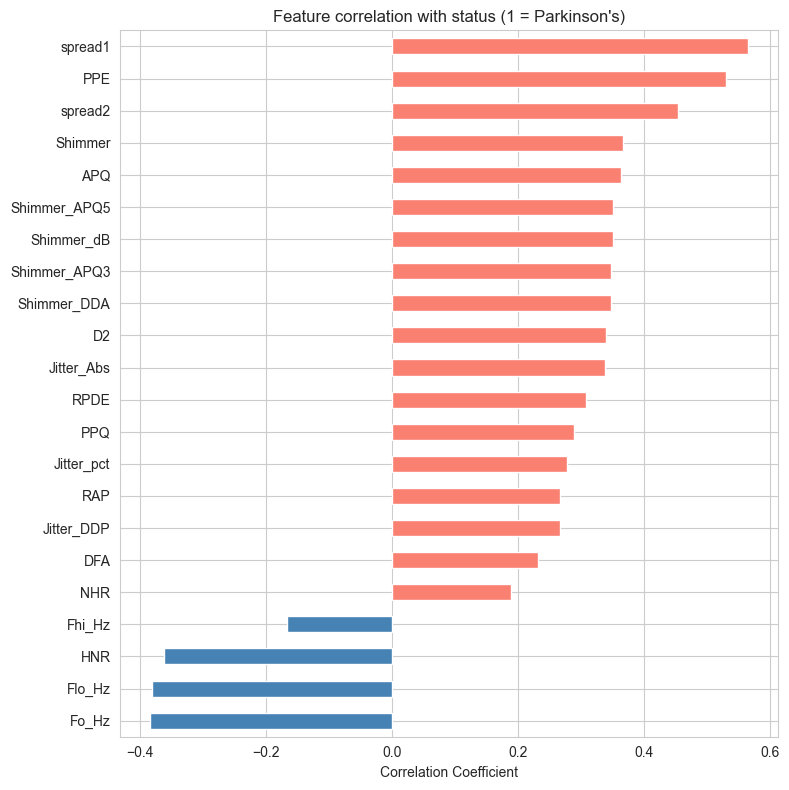

Top 10 features by absolute correlation with status:
spread1         0.565
PPE             0.531
spread2         0.455
Fo_Hz           0.384
Flo_Hz          0.380
Shimmer         0.367
APQ             0.364
HNR             0.362
Shimmer_APQ5    0.351
Shimmer_dB      0.351
Name: status, dtype: float64


In [14]:
target_corr = df_num.corr()["status"].drop("status").sort_values(ascending=False)
plt.figure(figsize=(8, 8))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with status (1 = Parkinson's)")
plt.xlabel("Correlation Coefficient"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print("Top 10 features by absolute correlation with status:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(3))

## 9. Jitter & Shimmer Deep-Dive

Jitter (cycle-to-cycle frequency variation) and shimmer (amplitude variation) are the canonical voice-quality measures used in PD research.

Jitter cols: ['Jitter_pct', 'Jitter_Abs', 'RAP', 'PPQ', 'Jitter_DDP']
Shimmer cols: ['Shimmer', 'Shimmer_dB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'Shimmer_DDA']


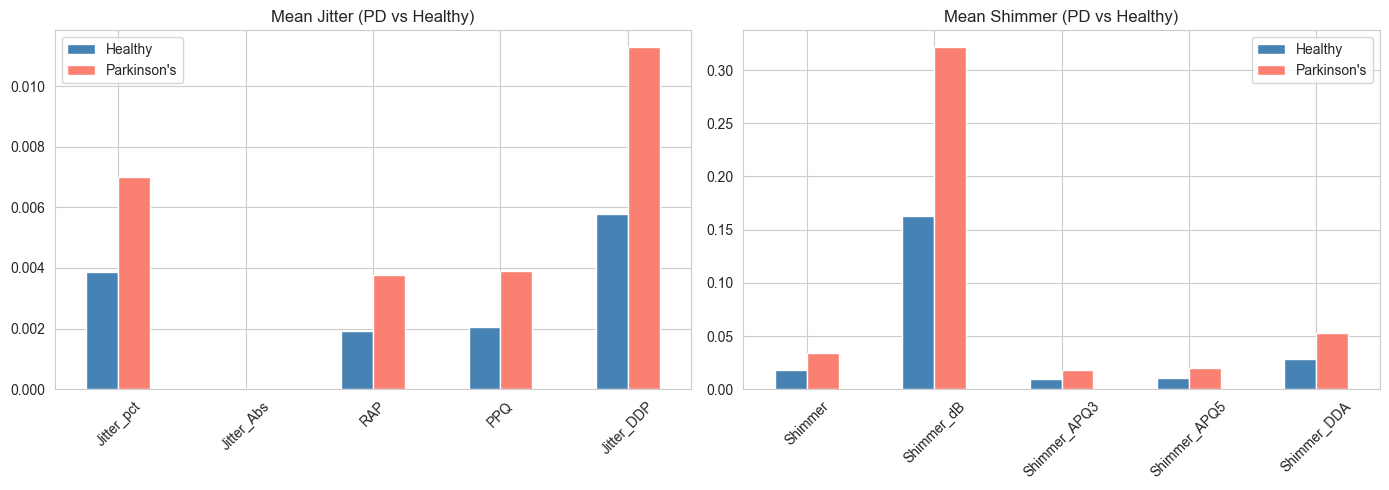

In [15]:
jitter_cols = [c for c in df.columns if c.startswith(("Jitter","RAP","PPQ"))]
shimmer_cols = [c for c in df.columns if c.startswith("Shimmer")]
print("Jitter cols:", jitter_cols)
print("Shimmer cols:", shimmer_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col_set, ax, title in [(jitter_cols, axes[0], "Mean Jitter (PD vs Healthy)"),
                           (shimmer_cols, axes[1], "Mean Shimmer (PD vs Healthy)")]:
    means = df.groupby("status")[col_set].mean().T
    means.columns = ["Healthy", "Parkinson's"]
    means.plot(kind="bar", ax=ax, color=["steelblue", "salmon"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 10. Pair Plot — Top Predictors

Top 4 features by abs correlation: ['spread1', 'PPE', 'spread2', 'Fo_Hz']


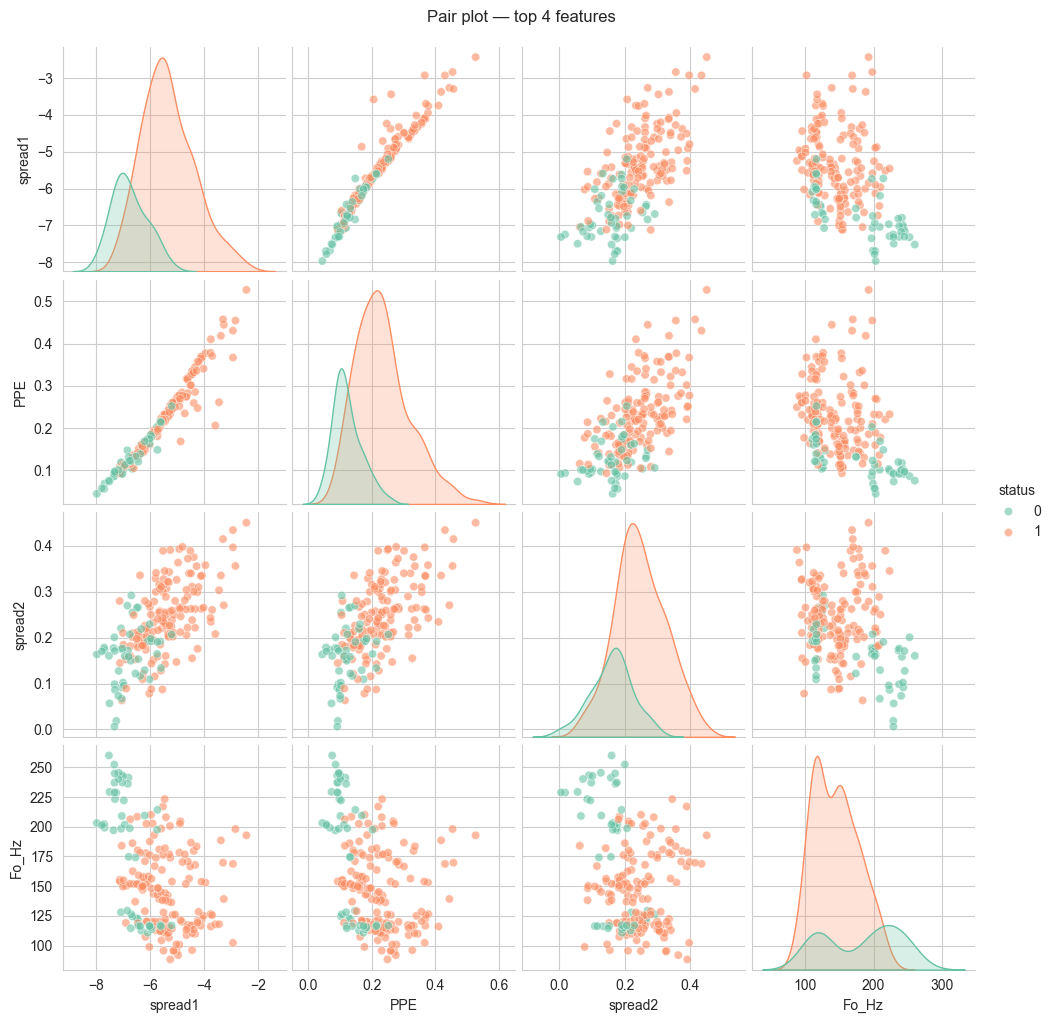

In [16]:
top4 = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()
print("Top 4 features by abs correlation:", top4)
sns.pairplot(df_num[top4 + ["status"]], hue="status", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.6})
plt.suptitle("Pair plot — top 4 features", y=1.02)
plt.show()

## 11. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Heavy class imbalance**: 75% Parkinson's vs 25% healthy — but in the *opposite* direction from many medical datasets (PD is the majority here) |
| 2 | **`spread1`, `PPE`, `spread2`** are the strongest single predictors of PD (all r > 0.4 in absolute value) |
| 3 | **Jitter and shimmer measures** are systematically higher in PD voices — voice instability is a hallmark of the disease |
| 4 | **HNR (harmonics-to-noise ratio) is lower in PD** — noisier voice signal |
| 5 | **Heavy intercorrelation** within the jitter group and within the shimmer group — multicollinearity is severe |
| 6 | **No missing values** — UCI Parkinson's is clean |
| 7 | **Subjects are not independent**: 6–7 recordings per subject means we should think about subject-level cross-validation in future work |